<a href="https://colab.research.google.com/github/sajib006/ML-Projects/blob/main/dhaka_delivery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ubr.csv")
df.head()

,start_time,end_time,pickup_location,drop_location,jam_condition,pickup_latitude,pickup_longitude,drop_latitude,drop_longitude
0,2025-11-22 03:49:03,2025-11-22 04:08:03,Mirpur 10,Khilkhet,Low,23.856643,90.357285,23.848675,90.378294
1,2025-11-23 00:39:48,2025-11-23 01:20:48,Motijheel,Bashundhara,Medium,23.884960,90.379155,23.845313,90.436354
2,2025-11-09 01:30:52,2025-11-09 02:18:52,Dhanmondi 27,Khilkhet,Low,23.857409,90.420815,23.853561,90.448798
3,2025-11-02 19:51:48,2025-11-02 20:12:48,Dhanmondi 27,Gulshan 1,Low,23.728257,90.374761,23.743696,90.411059
4,2025-11-26 14:44:37,2025-11-26 15:26:37,Mirpur 10,Banani,Low,23.869412,90.385612,23.852760,90.434576


In [ ]:
df['start_time'] = pd.to_datetime(df['start_time'])
df['end_time'] = pd.to_datetime(df['end_time'])

In [ ]:
df['delivery_minutes'] = (df['end_time'] - df['start_time']).dt.total_seconds() / 60


In [ ]:
df['hour'] = df['start_time'].dt.hour


In [ ]:
hourly_avg = df.groupby('hour')['delivery_minutes'].mean().reset_index()

print("Average delivery time per hour:")
print(hourly_avg)

Average delivery time per hour:
    hour  delivery_minutes
0      0         36.136364
1      1         37.097561
2      2         39.400000
3      3         38.625000
4      4         33.294118
5      5         38.681818
6      6         35.634146
7      7         35.240741
8      8         36.891892
9      9         38.146341
10    10         37.675000
11    11         37.472222
12    12         36.944444
13    13         38.232558
14    14         32.068182
15    15         34.257143
16    16         39.595238
17    17         36.047619
18    18         38.121212
19    19         34.809524
20    20         36.785714
21    21         39.265306
22    22         39.891304
23    23         37.500000


In [ ]:
jam_avg = df.groupby('jam_condition')['delivery_minutes'].mean().reset_index()
print("\nAverage delivery time per traffic condition:")
print(jam_avg)


Average delivery time per traffic condition:
  jam_condition  delivery_minutes
0          High         37.281899
1           Low         36.567485
2        Medium         37.267062


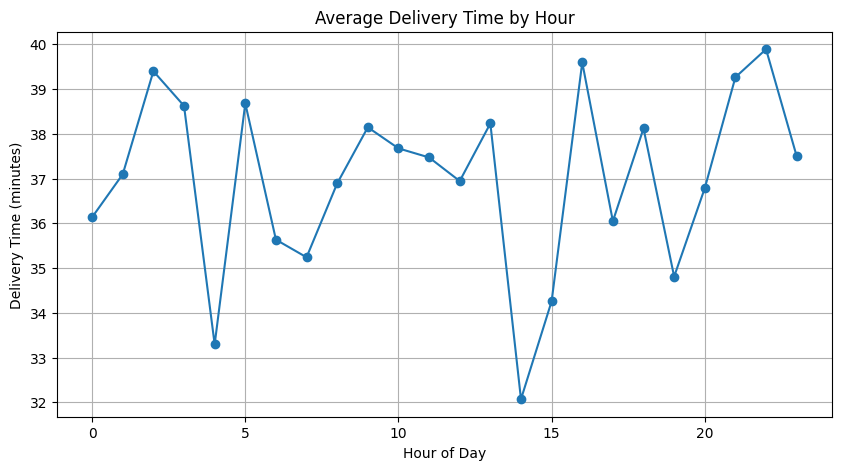

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(hourly_avg['hour'], hourly_avg['delivery_minutes'], marker='o')
plt.title("Average Delivery Time by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Delivery Time (minutes)")
plt.grid(True)
plt.show()

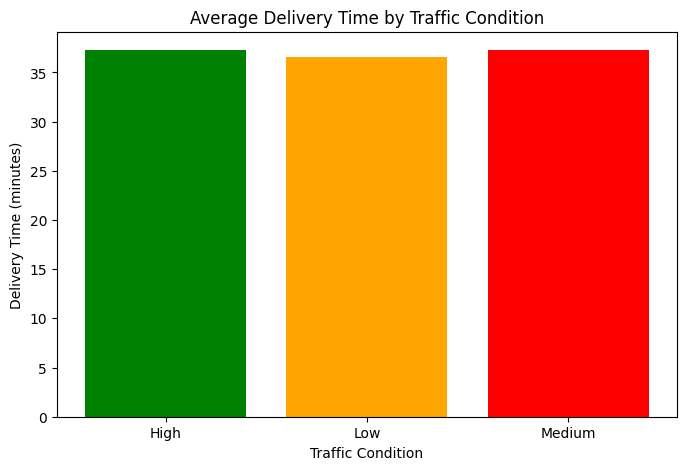

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(jam_avg['jam_condition'], jam_avg['delivery_minutes'], color=['green','orange','red'])
plt.title("Average Delivery Time by Traffic Condition")
plt.xlabel("Traffic Condition")
plt.ylabel("Delivery Time (minutes)")
plt.show()